# Data Science Job Market Analysis
## NLP Analysis of Current DS/ML Job Postings

An NLP project analyzing 100 current remote data science and machine learning 
job postings collected via the JSearch API. Covers text cleaning, skill extraction, 
sentiment analysis, and market demand insights.

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

%matplotlib inline
sns.set_theme(style='darkgrid')


In [5]:
# Load the raw data
with open('jobs_raw.json', 'r') as f:
    # Load the data
    with open('jobs_raw.json', 'r') as f:
        jobs_raw = json.load(f)
    # Convert to DataFrame
    df = pd.DataFrame(jobs_raw)
    # Display basic info
    print(df.info())
    print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_id                      100 non-null    object 
 1   job_title                   100 non-null    object 
 2   employer_name               100 non-null    object 
 3   employer_logo               91 non-null     object 
 4   employer_website            70 non-null     object 
 5   job_publisher               100 non-null    object 
 6   job_employment_type         99 non-null     object 
 7   job_employment_types        100 non-null    object 
 8   job_apply_link              100 non-null    object 
 9   job_apply_is_direct         100 non-null    bool   
 10  apply_options               100 non-null    object 
 11  job_description             100 non-null    object 
 12  job_is_remote               100 non-null    bool   
 13  job_posted_at               100 non-

In [6]:
# remove extraneous or low information columns

cols = ['job_title', 'job_employment_type', 'job_description', 'job_is_remote', 'job_publisher']
df = df[cols].copy()

# perform basic cleaning
df = df.drop_duplicates(subset=['job_description'])
df = df.dropna(subset=['job_description'])
df = df.reset_index(drop=True)

print(f"Jobs after deduplication: {len(df)}")
print(f"\nJob titles:\n{df['job_title'].value_counts().head(10)}")
print(f"\nPublishers:\n{df['job_publisher'].value_counts()}")


Jobs after deduplication: 96

Job titles:
job_title
Remote MLOps Engineer - ML Infra Lead (AWS ML Cert)                                                    2
Junior Data Scientist with BI /Junior Machine Learning Engineer-remote//junior full stack developer    1
PhD Intern – AI/ML/NLP Engineer                                                                        1
Data Scientist (NLP Deep Learning Engineer)                                                            1
Lead AI Engineer - NLP Focus                                                                           1
AI / ML Engineer – Conversational AI & NLP (AWS Bedrock)-8 Week Project                                1
AI Engineer NLP (Python & Go – Bridging ML and Platform)                                               1
TikTok is hiring: CV/NLP/Multimodal LLM Machine Learning Engineer Graduate (TikT                       1
NLP Engineer - Production ML for PII Redaction (Remote)                                                1
Rem

## Section 1: Data Collection & Cleaning

Job postings collected via the JSearch API across 5 search terms:
- Data Scientist
- Machine Learning Engineer  
- Data Analyst
- NLP Engineer
- MLOps Engineer

**96 unique remote job postings** after removing 4 duplicates.

In [14]:
# Skills to extract from job descriptions
skills = {
    'Python': r'\bpython\b',
    'SQL': r'\bsql\b',
    'R': r'\b(r programming|r language|\br\b)',
    'PyTorch': r'\bpytorch\b',
    'TensorFlow': r'\btensorflow\b',
    'scikit-learn': r'\bscikit.learn\b',
    'NLP': r'\b(nlp|natural language processing)\b',
    'AWS': r'\baws\b',
    'Azure': r'\bazure\b',
    'GCP': r'\bgcp|google cloud\b',
    'Docker': r'\bdocker\b',
    'Spark': r'\bspark\b',
    'Tableau': r'\btableau\b',
    'PowerBI': r'\bpower.?bi\b',
    'Git': r'\bgit\b',
    'MLOps': r'\bmlops\b',
    'LLM': r'\b(llm|large language model)\b',
    'Kubernetes': r'\bkubernetes\b'
}


# using the defined skill patterns, extract skills from job descriptions

skill_counts = Counter()

for description in df['job_description']:
    desc_lower = description.lower()
    for skill, pattern in skills.items():
        if re.search(pattern, desc_lower, re.IGNORECASE):
            skill_counts[skill] += 1

# Convert to dataframe and sort
skills_df = pd.DataFrame(skill_counts.items(),
                         columns=['Skill', 'Count'])
skills_df['Percentage'] = (skills_df['Count'] / len(df) * 100).round(1)
skills_df = skills_df.sort_values('Count', ascending=False).reset_index(drop=True)

print(skills_df)


           Skill  Count  Percentage
0         Python     64        66.7
1            SQL     33        34.4
2            AWS     26        27.1
3            NLP     24        25.0
4          MLOps     22        22.9
5        PyTorch     18        18.8
6     TensorFlow     18        18.8
7            GCP     16        16.7
8            LLM     14        14.6
9          Azure     13        13.5
10         Spark     11        11.5
11           Git     11        11.5
12        Docker     11        11.5
13             R     10        10.4
14    Kubernetes      9         9.4
15       Tableau      9         9.4
16       PowerBI      7         7.3
17  scikit-learn      6         6.2


### Observations
- Python is non-negotiable — present in 67% of postings
- SQL remains critical at 34% — underestimated by many ML practitioners
- AWS dominates cloud at 27% vs Azure 14% and GCP 17%
- LLM demand at 15% signals market shift toward generative AI
- MLOps at 23% confirms production deployment skills are valued
- scikit-learn and Git are likely assumed rather than explicitly stated

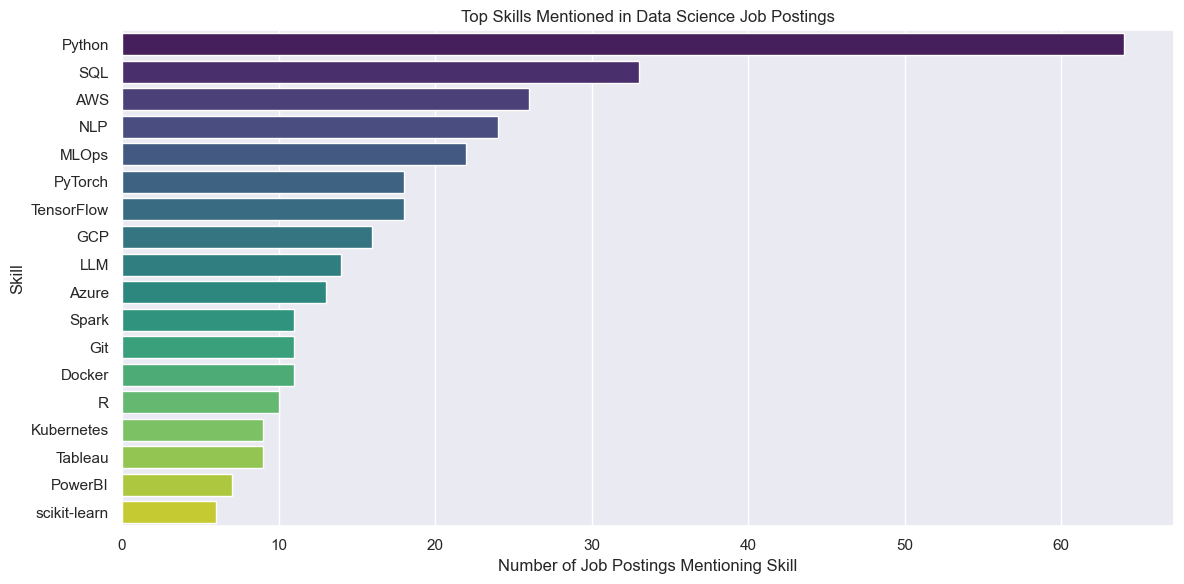

In [16]:
# create a bar chart of the top skills using skills_df
plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Skill', data=skills_df,
            hue='Skill', legend=False,
            order=skills_df['Skill'].tolist(), palette='viridis')
plt.title('Top Skills Mentioned in Data Science Job Postings')
plt.xlabel('Number of Job Postings Mentioning Skill')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()